In [20]:
!unzip /content/emotion_model_mobilenet_v2_224.h5.zip

Archive:  /content/emotion_model_mobilenet_v2_224.h5.zip
  inflating: emotion_model_mobilenet_v2_224.h5  
  inflating: __MACOSX/._emotion_model_mobilenet_v2_224.h5  


# Import required libraries

In [11]:
import tensorflow as tf
import numpy as np
import os
import random
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Set up Image Data Generator

In [3]:
test_dir = '/content/emotion_test/test'        # Folder containing test images in subfolders by class

# Set up ImageDataGenerator for test set
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),  # Make sure it matches your model input
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 84 images belonging to 7 classes.


# Test Base Model

In [21]:
model_path = '/content/emotion_model_mobilenet_v2_224.h5'

# Load model
model = load_model(model_path)
print("Model loaded successfully.")

Model loaded successfully.


In [22]:
# Evaluate model on test set
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5086 - loss: 1.5004
Test Loss: 1.2536
Test Accuracy: 0.5952


3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.33      0.50      0.40        12
     disgust       0.00      0.00      0.00        12
        fear       0.75      0.50      0.60        12
       happy       0.85      0.92      0.88        12
     neutral       0.44      0.67      0.53        12
         sad       0.57      0.67      0.62        12
    surprise       0.85      0.92      0.88        12

    accuracy                           0.60        84
   macro avg       0.54      0.60      0.56        84
weighted avg       0.54      0.60      0.56        84



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


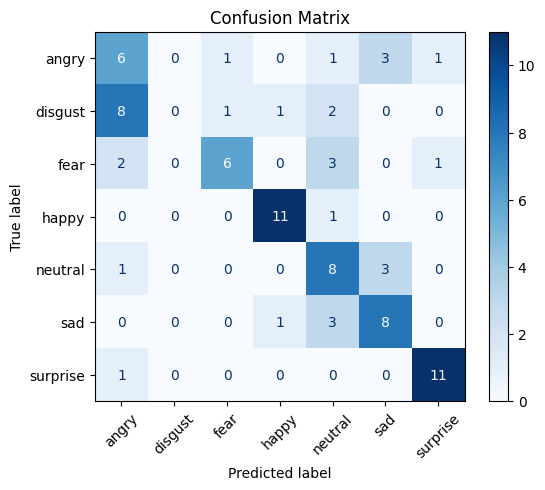

In [23]:
y_probs = model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


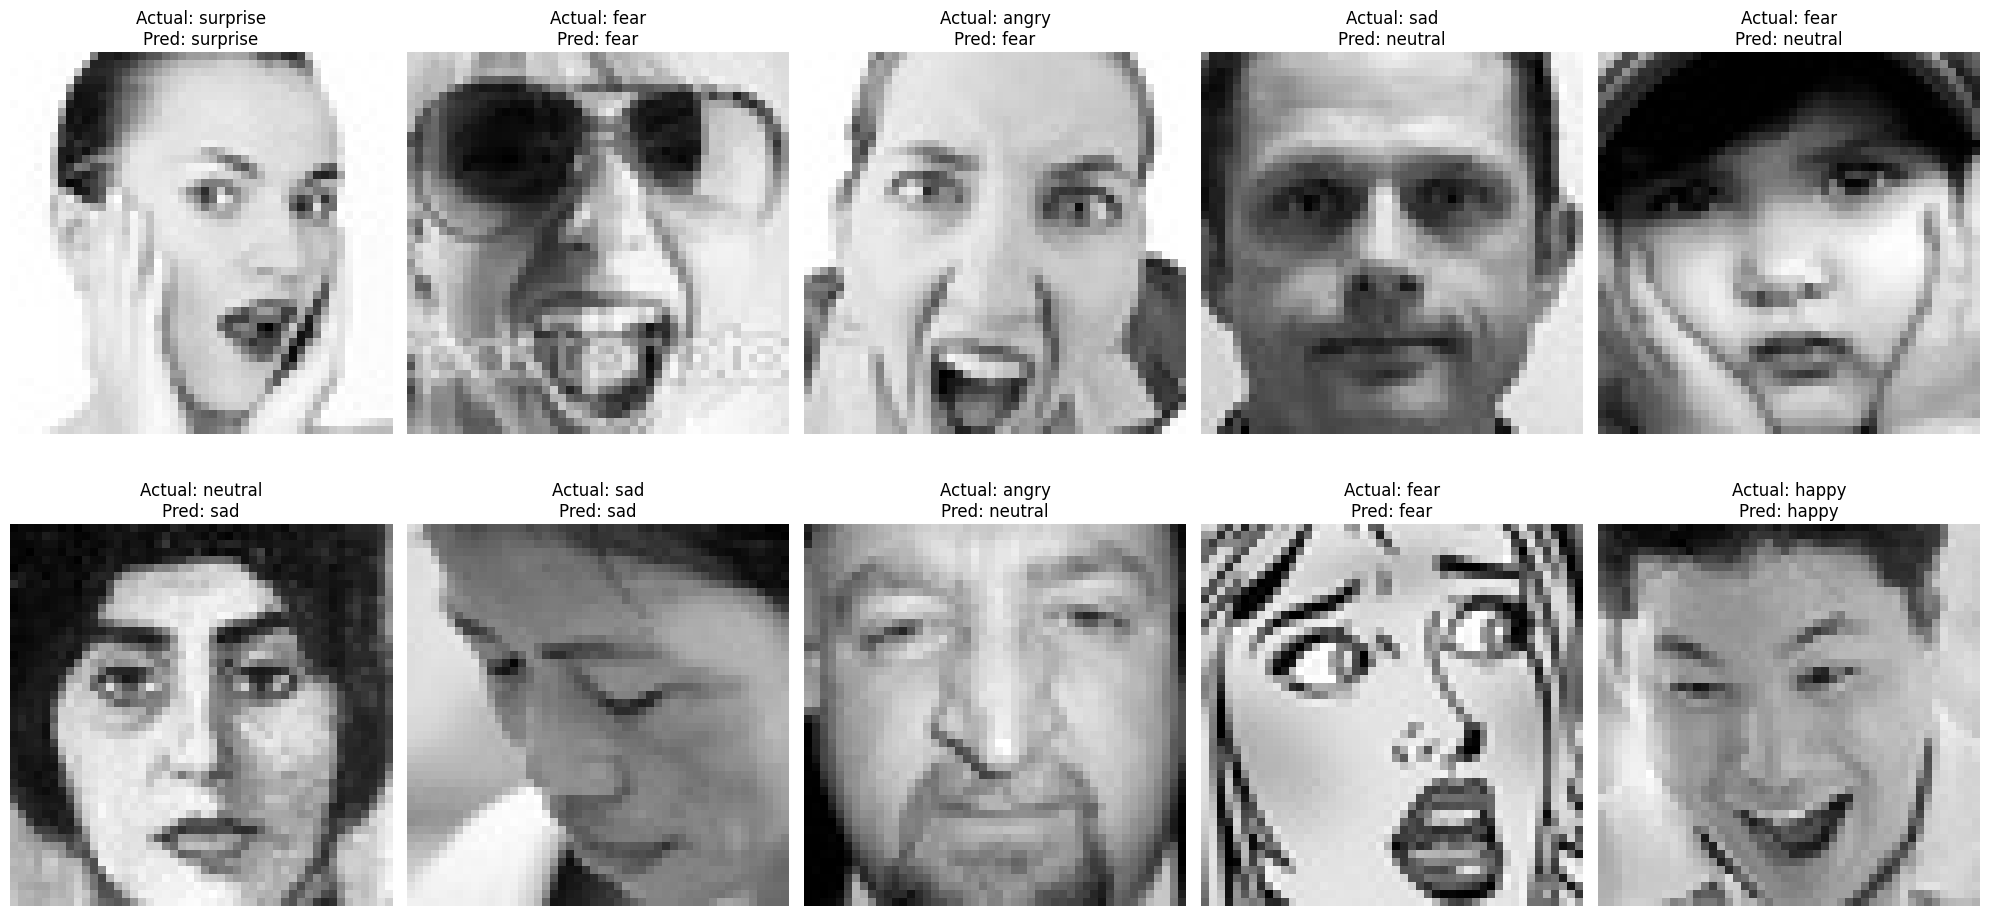

In [25]:
num_samples = 10
filepaths = test_generator.filepaths
true_labels = test_generator.classes
class_indices = test_generator.class_indices
inv_class_indices = {v: k for k, v in class_indices.items()}

sample_indices = random.sample(range(len(filepaths)), num_samples)

plt.figure(figsize=(20, 10))
for i, idx in enumerate(sample_indices):
    img_path = filepaths[idx]
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (48, 48))
    img_array = img_resized.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=-1)  # (48, 48, 1)
    img_array = np.expand_dims(img_array, axis=0)   # (1, 48, 48, 1)

    prediction = model.predict(img_array)
    predicted_label = np.argmax(prediction)
    actual_label = true_labels[idx]

    plt.subplot(2, 5, i+1)
    plt.imshow(img_gray, cmap='gray')
    plt.axis('off')
    plt.title(f"Actual: {inv_class_indices[actual_label]}\nPred: {inv_class_indices[predicted_label]}", fontsize=12)

plt.tight_layout()
plt.show()
